<a href="https://www.kaggle.com/code/lalit7881/global-food-security-intelligence-eda?scriptVersionId=310169216" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/global-food-security-intelligence/global_food_security_intelligence.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/global-food-security-intelligence/global_food_security_intelligence.csv")

In [3]:
df.head()

,country_code,iso3,country_name,year,region,income_group,lending_type,capital_city,latitude,longitude,...,food_crop_production_gap,protein_adequacy_score,agriculture_dependence_index,undernourishment_yoy_change_pp,row_completeness_pct,country_iso3,data_version,compiled_date,source_wb,source_fao
0,ABW,ABW,Aruba,2000,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
1,ABW,ABW,Aruba,2001,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
2,ABW,ABW,Aruba,2002,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
3,ABW,ABW,Aruba,2003,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
4,ABW,ABW,Aruba,2004,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download


In [4]:
df.tail()

,country_code,iso3,country_name,year,region,income_group,lending_type,capital_city,latitude,longitude,...,food_crop_production_gap,protein_adequacy_score,agriculture_dependence_index,undernourishment_yoy_change_pp,row_completeness_pct,country_iso3,data_version,compiled_date,source_wb,source_fao
5203,ZWE,ZWE,Zimbabwe,2019,Sub-Saharan Africa,Lower middle income,Blend,Harare,-17.8312,31.0672,...,1.45,100.0,52.11,-1.0,100.0,ZW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
5204,ZWE,ZWE,Zimbabwe,2020,Sub-Saharan Africa,Lower middle income,Blend,Harare,-17.8312,31.0672,...,-17.43,100.0,50.21,-1.8,91.7,ZW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
5205,ZWE,ZWE,Zimbabwe,2021,Sub-Saharan Africa,Lower middle income,Blend,Harare,-17.8312,31.0672,...,-9.45,100.0,47.72,-3.4,91.7,ZW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
5206,ZWE,ZWE,Zimbabwe,2022,Sub-Saharan Africa,Lower middle income,Blend,Harare,-17.8312,31.0672,...,-1.80,NaN,47.56,-3.4,83.3,ZW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
5207,ZWE,ZWE,Zimbabwe,2023,Sub-Saharan Africa,Lower middle income,Blend,Harare,-17.8312,31.0672,...,NaN,NaN,48.62,-1.7,58.3,ZW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5208 entries, 0 to 5207
Data columns (total 57 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   country_code                           5208 non-null   object 
 1   iso3                                   5208 non-null   object 
 2   country_name                           5208 non-null   object 
 3   year                                   5208 non-null   int64  
 4   region                                 5208 non-null   object 
 5   income_group                           5208 non-null   object 
 6   lending_type                           5208 non-null   object 
 7   capital_city                           5064 non-null   object 
 8   latitude                               5064 non-null   float64
 9   longitude                              5064 non-null   float64
 10  agricultural_land_pct                  5002 non-null   float64
 11  arab

In [6]:
df.describe()

,year,latitude,longitude,agricultural_land_pct,arable_land_pct,cereal_yield_kg_per_ha,child_mortality_per_1000,crop_production_index,employment_in_agriculture_pct,food_imports_pct_merchandise,...,fao_undernourishment_pct,hunger_severity_index,economic_vulnerability_index,food_crisis_flag,undernourished_pop_millions,food_crop_production_gap,protein_adequacy_score,agriculture_dependence_index,undernourishment_yoy_change_pp,row_completeness_pct
count,5208.000000,5064.000000,5064.000000,5002.000000,4908.000000,4274.000000,4704.000000,4449.000000,4484.000000,4252.000000,...,2610.000000,5208.000000,5208.000000,5208.000000,3874.000000,4449.000000,3551.000000,5208.000000,3662.000000,5208.000000
mean,2011.500000,18.889009,19.139549,37.260159,13.814459,3317.106949,36.993729,94.955577,25.955071,48.006711,...,13.802989,11.529894,34.159681,0.084101,5.601348,-0.709042,99.105080,29.066655,-0.202021,75.616494
std,6.922851,24.155822,70.231002,22.364813,13.614578,2996.881343,41.170921,27.080823,22.549113,29.480795,...,10.539894,11.562730,6.082914,0.277566,18.063315,12.578813,4.264154,18.136492,1.082634,22.267372
min,2000.000000,-41.286500,-175.216000,0.436116,0.043141,0.100000,1.400000,17.000000,0.079580,1.127673,...,2.500000,0.000000,0.810000,0.000000,0.002000,-170.740000,56.920000,0.000000,-11.500000,8.300000
25%,2005.750000,4.174200,-15.180400,18.237651,3.053737,1497.600000,8.400000,82.620000,5.323499,28.948272,...,5.500000,1.590000,31.930000,0.000000,0.200000,-3.520000,100.000000,14.455000,-0.500000,66.700000
50%,2011.500000,17.300000,19.259500,38.504155,9.886758,2682.800000,20.200000,95.990000,18.738900,41.102967,...,10.300000,7.500000,34.100000,0.000000,1.027500,0.060000,100.000000,28.785000,0.000000,83.300000
75%,2017.250000,40.049500,50.535400,54.011606,19.914663,4252.325000,51.625000,104.720000,42.585908,59.986487,...,18.900000,18.962500,35.250000,0.000000,3.990250,3.570000,100.000000,41.362500,0.100000,91.700000
max,2023.000000,64.183600,179.089567,86.475816,64.146885,36761.900000,478.900000,625.430000,91.937552,429.359095,...,67.800000,54.930000,93.540000,1.000000,246.510000,119.110000,100.000000,84.740000,7.400000,100.000000


In [7]:
df.isnull().sum()

country_code                                0
iso3                                        0
country_name                                0
year                                        0
region                                      0
income_group                                0
lending_type                                0
capital_city                              144
latitude                                  144
longitude                                 144
agricultural_land_pct                     206
arable_land_pct                           300
cereal_yield_kg_per_ha                    934
child_mortality_per_1000                  504
crop_production_index                     759
employment_in_agriculture_pct             724
food_imports_pct_merchandise              956
food_production_index                     759
freshwater_withdrawal_pct                1255
gdp_per_capita_usd                        167
inflation_consumer_prices_pct             863
population_total                  

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['country_code', 'iso3', 'country_name', 'year', 'region',
       'income_group', 'lending_type', 'capital_city', 'latitude', 'longitude',
       'agricultural_land_pct', 'arable_land_pct', 'cereal_yield_kg_per_ha',
       'child_mortality_per_1000', 'crop_production_index',
       'employment_in_agriculture_pct', 'food_imports_pct_merchandise',
       'food_production_index', 'freshwater_withdrawal_pct',
       'gdp_per_capita_usd', 'inflation_consumer_prices_pct',
       'population_total', 'poverty_headcount_pct', 'stunting_prevalence_pct',
       'undernourishment_pct', 'fao_animal_protein_g_per_day',
       'fao_basic_sanitation_pct', 'fao_basic_water_access_pct',
       'fao_cereal_import_dependency_pct', 'fao_child_stunting_millions',
       'fao_child_stunting_pct', 'fao_child_wasting_millions',
       'fao_dietary_energy_adequacy_pct', 'fao_fat_supply_g_per_day',
       'fao_gdp_per_capita_ppp', 'fao_low_birthweight_millions',
       'fao_min_dietary_energy_req_kcal',
  

In [10]:
df.dtypes

country_code                              object
iso3                                      object
country_name                              object
year                                       int64
region                                    object
income_group                              object
lending_type                              object
capital_city                              object
latitude                                 float64
longitude                                float64
agricultural_land_pct                    float64
arable_land_pct                          float64
cereal_yield_kg_per_ha                   float64
child_mortality_per_1000                 float64
crop_production_index                    float64
employment_in_agriculture_pct            float64
food_imports_pct_merchandise             float64
food_production_index                    float64
freshwater_withdrawal_pct                float64
gdp_per_capita_usd                       float64
inflation_consumer_p

In [11]:
df.shape

(5208, 57)

In [12]:
df.nunique()

country_code                              217
iso3                                      217
country_name                              217
year                                       24
region                                      7
income_group                                5
lending_type                                4
capital_city                              211
latitude                                  211
longitude                                 211
agricultural_land_pct                    3693
arable_land_pct                          3189
cereal_yield_kg_per_ha                   4104
child_mortality_per_1000                 1199
crop_production_index                    3244
employment_in_agriculture_pct            4484
food_imports_pct_merchandise             4252
food_production_index                    3140
freshwater_withdrawal_pct                2503
gdp_per_capita_usd                       5041
inflation_consumer_prices_pct            4345
population_total                  

In [13]:
# Drop duplicates
df = df.drop_duplicates()

# Handle missing values (simple approach)
df = df.fillna(method='ffill')

# Convert year to int
df['year'] = df['year'].astype(int)

## EDA

In [14]:
plt.style.use('default')
sns.set_theme(style="whitegrid")

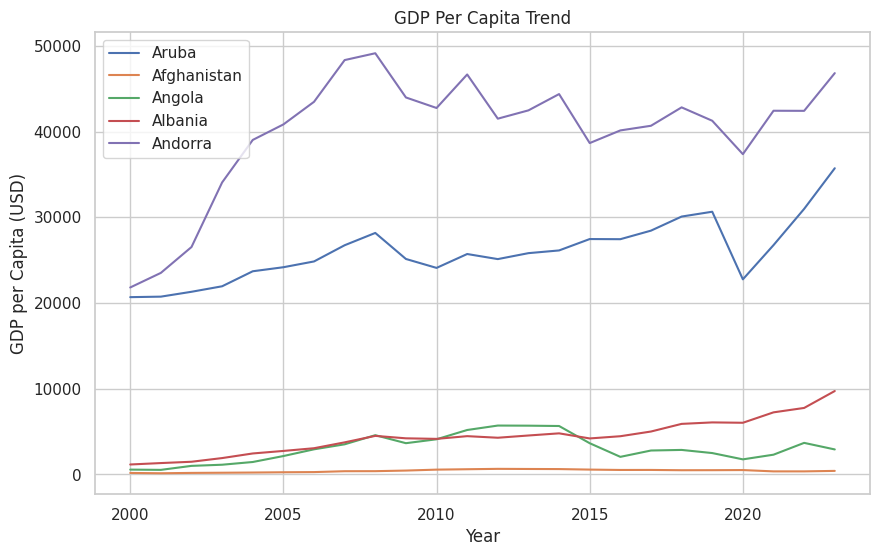

In [15]:
plt.figure(figsize=(10,6))
for country in df['country_name'].unique()[:5]:
    subset = df[df['country_name'] == country]
    plt.plot(subset['year'], subset['gdp_per_capita_usd'], label=country)

plt.title("GDP Per Capita Trend")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (USD)")
plt.legend()
plt.show()

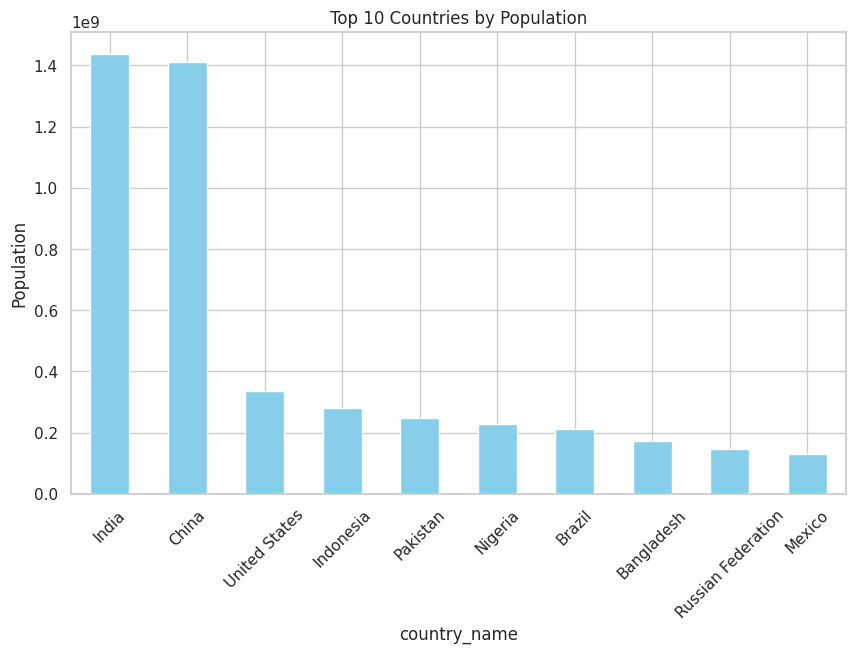

In [16]:
top_pop = df.groupby('country_name')['population_total'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_pop.plot(kind='bar', color='skyblue')
plt.title("Top 10 Countries by Population")
plt.ylabel("Population")
plt.xticks(rotation=45)
plt.show()

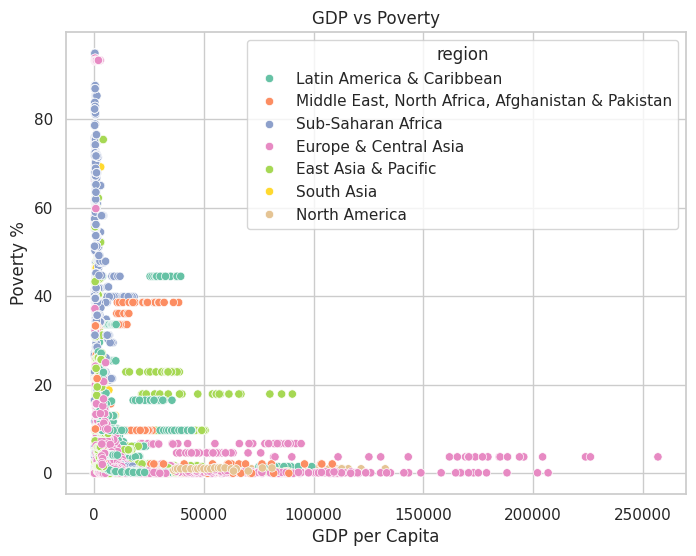

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='gdp_per_capita_usd',
    y='poverty_headcount_pct',
    hue='region',
    palette='Set2'
)

plt.title("GDP vs Poverty")
plt.xlabel("GDP per Capita")
plt.ylabel("Poverty %")
plt.show()

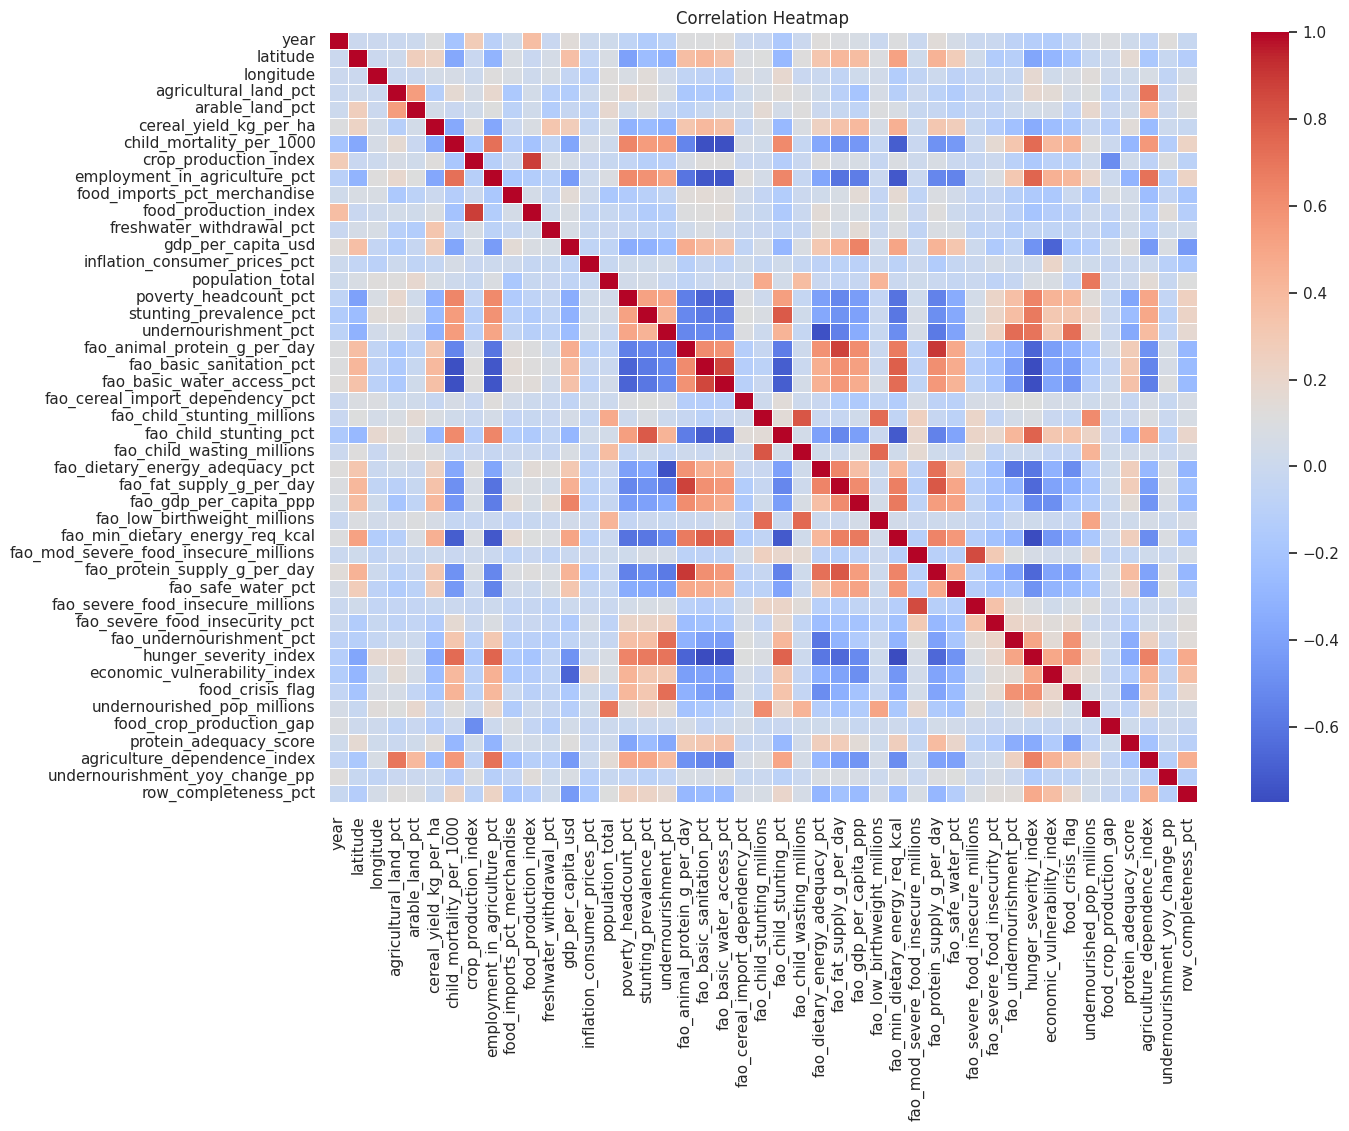

In [18]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

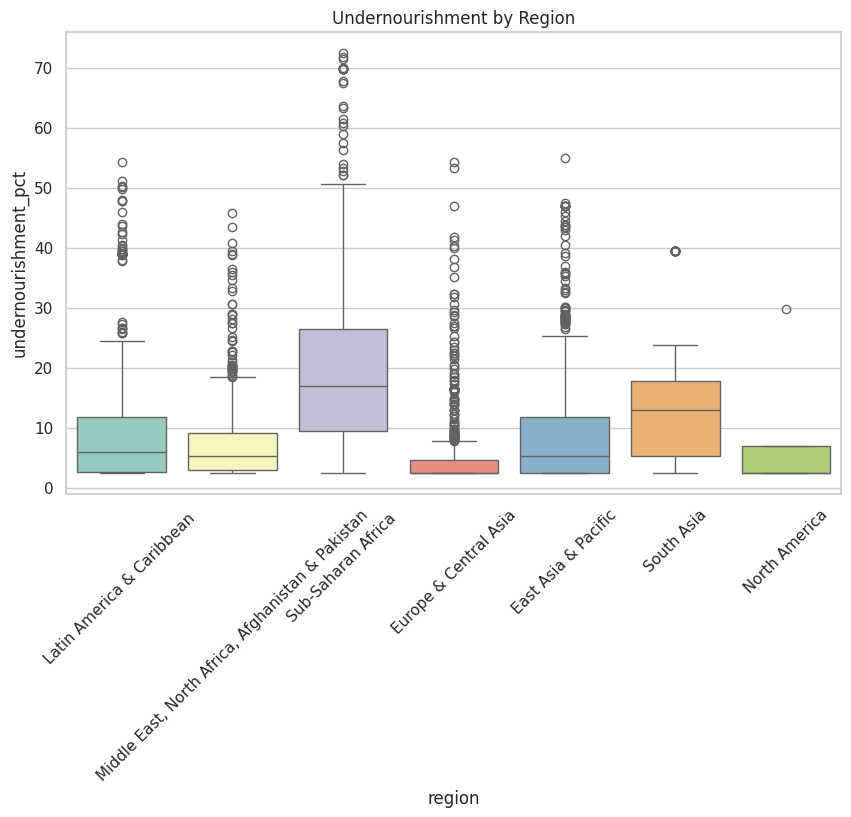

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='region',
    y='undernourishment_pct',
    palette='Set3'
)

plt.xticks(rotation=45)
plt.title("Undernourishment by Region")
plt.show()

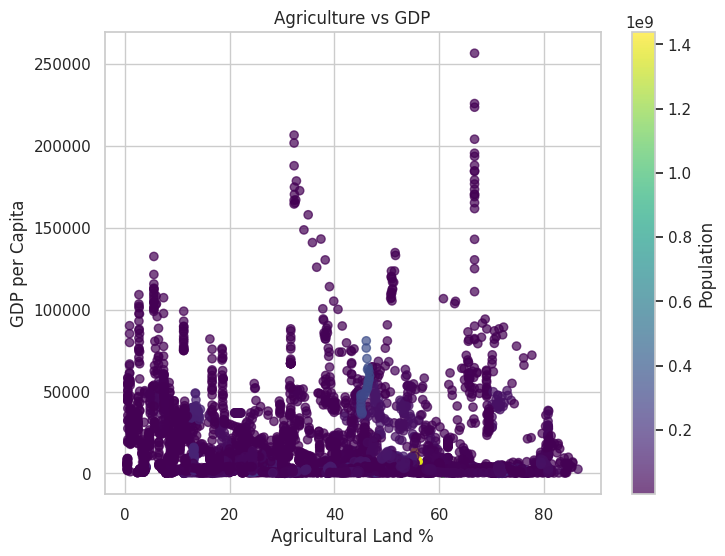

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['agricultural_land_pct'],
    df['gdp_per_capita_usd'],
    c=df['population_total'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(label='Population')
plt.xlabel("Agricultural Land %")
plt.ylabel("GDP per Capita")
plt.title("Agriculture vs GDP")
plt.show()

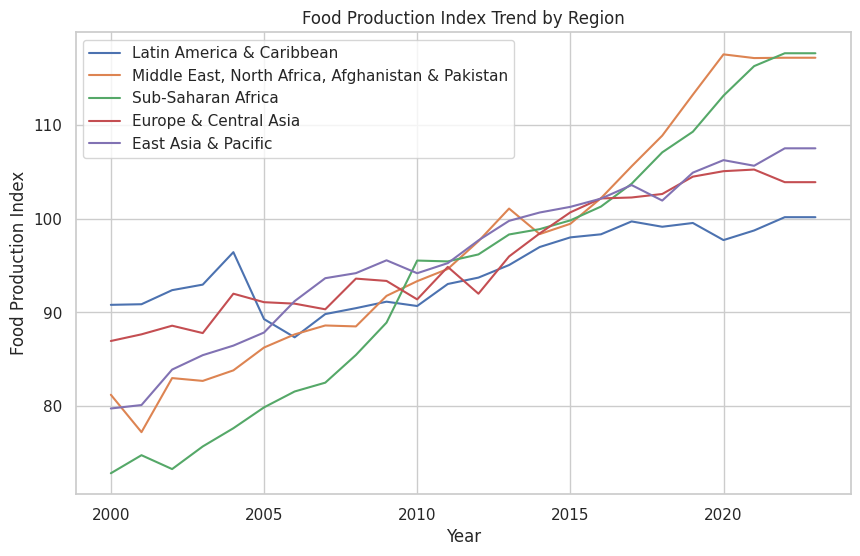

In [21]:
plt.figure(figsize=(10,6))

for region in df['region'].unique()[:5]:
    subset = df[df['region'] == region]
    grouped = subset.groupby('year')['food_production_index'].mean()
    plt.plot(grouped.index, grouped.values, label=region)

plt.legend()
plt.title("Food Production Index Trend by Region")
plt.xlabel("Year")
plt.ylabel("Food Production Index")
plt.show()

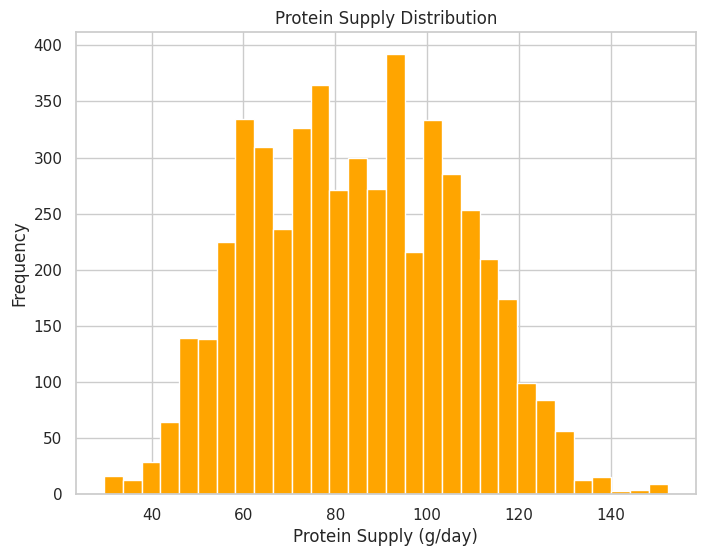

In [22]:
plt.figure(figsize=(8,6))

plt.hist(df['fao_protein_supply_g_per_day'], bins=30, color='orange')

plt.title("Protein Supply Distribution")
plt.xlabel("Protein Supply (g/day)")
plt.ylabel("Frequency")
plt.show()

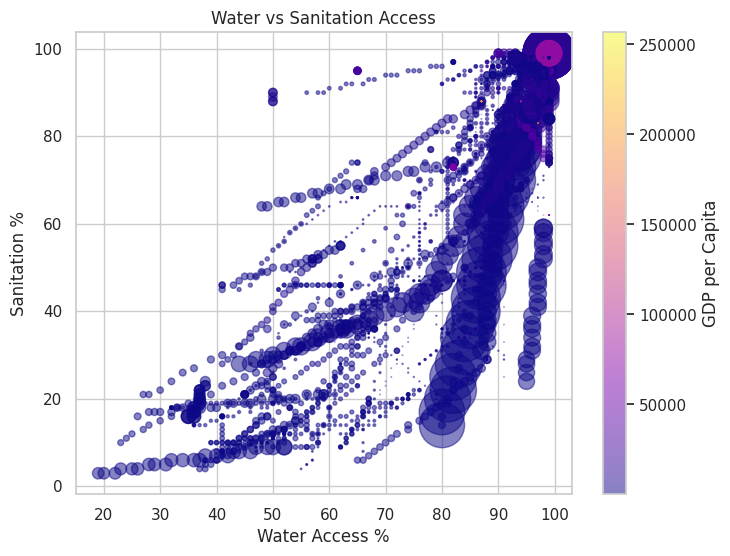

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['fao_basic_water_access_pct'],
    df['fao_basic_sanitation_pct'],
    s=df['population_total'] / 1e6,
    alpha=0.5,
    c=df['gdp_per_capita_usd'],
    cmap='plasma'
)

plt.colorbar(label="GDP per Capita")
plt.xlabel("Water Access %")
plt.ylabel("Sanitation %")
plt.title("Water vs Sanitation Access")
plt.show()

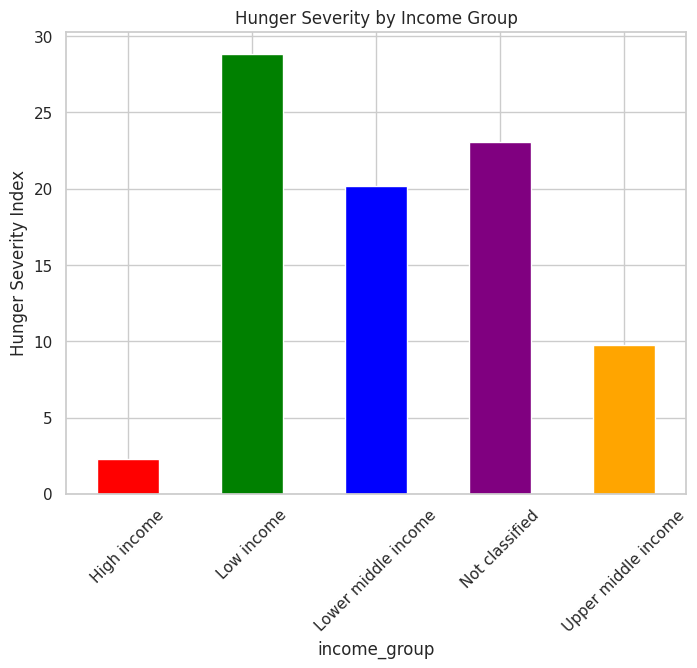

In [24]:
grouped = df.groupby('income_group')['hunger_severity_index'].mean()

plt.figure(figsize=(8,6))
grouped.plot(kind='bar', color=['red','green','blue','purple','orange'])

plt.title("Hunger Severity by Income Group")
plt.ylabel("Hunger Severity Index")
plt.xticks(rotation=45)
plt.show()

## Feature engineering

(5208, 57)
  country_code iso3 country_name  year                      region  \
0          ABW  ABW        Aruba  2000  Latin America & Caribbean    
1          ABW  ABW        Aruba  2001  Latin America & Caribbean    
2          ABW  ABW        Aruba  2002  Latin America & Caribbean    
3          ABW  ABW        Aruba  2003  Latin America & Caribbean    
4          ABW  ABW        Aruba  2004  Latin America & Caribbean    

  income_group    lending_type capital_city  latitude  longitude  ...  \
0  High income  Not classified   Oranjestad   12.5167   -70.0167  ...   
1  High income  Not classified   Oranjestad   12.5167   -70.0167  ...   
2  High income  Not classified   Oranjestad   12.5167   -70.0167  ...   
3  High income  Not classified   Oranjestad   12.5167   -70.0167  ...   
4  High income  Not classified   Oranjestad   12.5167   -70.0167  ...   

   food_crop_production_gap  protein_adequacy_score  \
0                       NaN                     NaN   
1                  

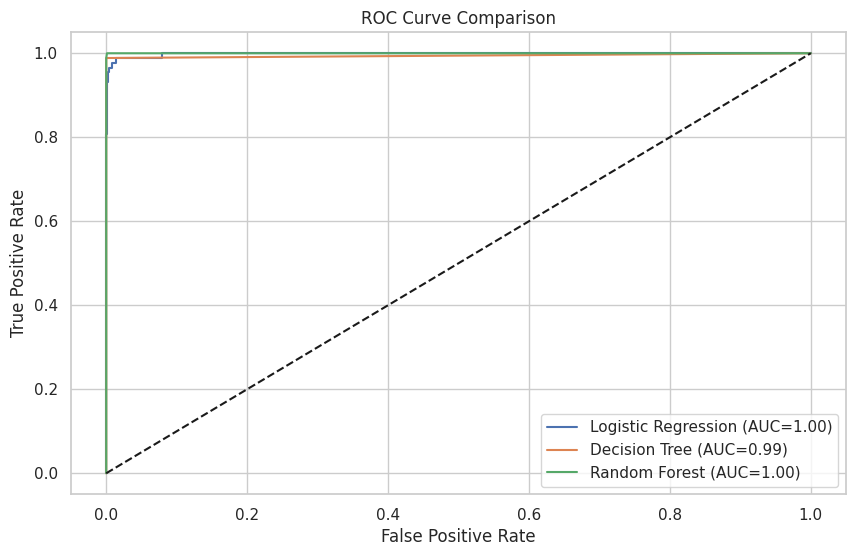


Model Performance:

                     Accuracy       AUC
Logistic Regression  0.992322  0.998606
Decision Tree        0.999040  0.994318
Random Forest        0.999040  0.999994


In [25]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# ================================
# 2. LOAD DATA
# ================================

print(df.shape)
print(df.head())


# ================================
# 3. TARGET VARIABLE
# ================================
df['food_crisis_flag'] = df['food_crisis_flag'].astype(int)
target = 'food_crisis_flag'


# ================================
# 4. DROP USELESS COLUMNS
# ================================
drop_cols = [
    'country_code', 'iso3', 'country_name', 'capital_city',
    'data_version', 'compiled_date', 'source_wb', 'source_fao'
]

df = df.drop(columns=drop_cols, errors='ignore')


# ================================
# 5. SPLIT FEATURES & TARGET
# ================================
X = df.drop(columns=[target])
y = df[target]


# ================================
# 6. TRAIN TEST SPLIT (NO LEAKAGE)
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ================================
# 7. COLUMN TYPES
# ================================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)


# ================================
# 8. PREPROCESSING PIPELINE (FIX NaN)
# ================================

# Numerical pipeline
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_cols),
        ('cat', cat_pipeline, categorical_cols)
    ]
)


# ================================
# 9. MODELS
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


# ================================
# 10. TRAIN + EVALUATE
# ================================
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {"Accuracy": acc, "AUC": auc}
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")


# ================================
# 11. ROC CURVE PLOT
# ================================
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# ================================
# 12. FINAL RESULTS
# ================================
results_df = pd.DataFrame(results).T
print("\nModel Performance:\n")
print(results_df)

## Thank you..pls upvote!!!!!!!!!